In [ ]:
import os
import numpy as np
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
print("GPUs available:", gpus)
if not gpus:
    print("WARNING: No GPU detected. In Colab go to Runtime > Change runtime type > T4 GPU, "
          "then Reconnect, before running this cell. Training on CPU will be 10-20x slower.")
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
import matplotlib
import matplotlib.pyplot as plt

import glob
import random
import shutil

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# =========================================================
# 1. CONFIG — set these to your ACTUAL Drive folder paths
#    (your Drive has flat folders, not train/real, train/fake
#    subfolders — this script is written for that structure)
# =========================================================
REAL_TRAIN_DIR = "/content/drive/MyDrive/qr_dataset/real_qr_full/real_qr_full"
FAKE_TRAIN_DIR = "/content/drive/MyDrive/qr_dataset/fake_qr_full/fake_qr_full"
REAL_TEST_DIR  = "/content/drive/MyDrive/qr_dataset/real_qr_test/real_qr_test"
FAKE_TEST_DIR  = "/content/drive/MyDrive/qr_dataset/fake_qr_test"


In [ ]:
import pandas as pd
t = pd.read_csv('/content/drive/MyDrive/qr_dataset/fake_qr_test/tamper_log_test.csv')
print(t.category.value_counts())

category
module_corruption    1508
patch_overlay        1492
Name: count, dtype: int64


In [ ]:
!rm -rf /content/local_qr_data

In [ ]:
# Reading thousands of small files directly from a mounted Drive is very
# slow (network I/O per file). Copy once to local Colab disk, then read
# from there — this alone usually fixes most of the slowness.
LOCAL_BASE = "/content/local_qr_data"
REAL_TRAIN_DIR = os.path.join(LOCAL_BASE, "real_train")
FAKE_TRAIN_DIR = os.path.join(LOCAL_BASE, "fake_train")
REAL_TEST_DIR  = os.path.join(LOCAL_BASE, "real_test")
FAKE_TEST_DIR  = os.path.join(LOCAL_BASE, "fake_test")

def copy_once(src, dst):
    if os.path.isdir(dst) and len(os.listdir(dst)) > 0:
        print(f"Already copied: {dst} ({len(os.listdir(dst))} files)")
        return
    print(f"Copying {src} -> {dst} ...")
    shutil.copytree(src, dst, dirs_exist_ok=True)
    print(f"Done: {len(os.listdir(dst))} files")

copy_once(DRIVE_REAL_TRAIN_DIR, REAL_TRAIN_DIR)
copy_once(DRIVE_FAKE_TRAIN_DIR, FAKE_TRAIN_DIR)
copy_once(DRIVE_REAL_TEST_DIR, REAL_TEST_DIR)
copy_once(DRIVE_FAKE_TEST_DIR, FAKE_TEST_DIR)

IMG_SIZE  = (224, 224)     # EfficientNetB0 default input size
BATCH_SIZE = 32
EPOCHS_FROZEN = 8
EPOCHS_FINETUNE = 10
VAL_SPLIT = 0.15

# label convention: 1 = real, 0 = fake
CLASS_NAMES = ["fake", "real"]

# =========================================================
# 2. LOAD DATA — built manually from your 4 flat folders
# =========================================================
def find_pngs(folder):
    """Recursively find pngs — handles cases where a zip extracted into
    a nested subfolder of the same name (e.g. real_qr_full/real_qr_full/*.png)."""
    return sorted(glob.glob(os.path.join(folder, "**", "*.png"), recursive=True))

real_train_files = find_pngs(REAL_TRAIN_DIR)
fake_train_files = find_pngs(FAKE_TRAIN_DIR)
real_test_files  = find_pngs(REAL_TEST_DIR)
fake_test_files  = find_pngs(FAKE_TEST_DIR)

print("real train:", len(real_train_files), "fake train:", len(fake_train_files))
print("real test:", len(real_test_files), "fake test:", len(fake_test_files))
assert len(real_train_files) > 0, f"No files found in {REAL_TRAIN_DIR} — check the path"
assert len(fake_train_files) > 0, f"No files found in {FAKE_TRAIN_DIR} — check the path"

all_train_files = real_train_files + fake_train_files
all_train_labels = [1] * len(real_train_files) + [0] * len(fake_train_files)

combined = list(zip(all_train_files, all_train_labels))
random.seed(42)
random.shuffle(combined)
split_idx = int(len(combined) * (1 - VAL_SPLIT))
train_pairs, val_pairs = combined[:split_idx], combined[split_idx:]
train_files, train_labels = zip(*train_pairs)
val_files, val_labels = zip(*val_pairs)

test_files = real_test_files + fake_test_files
test_labels = [1] * len(real_test_files) + [0] * len(fake_test_files)


def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    return img, label


def make_ds(files, labels, batch_size, shuffle=False, cache_path=None):
    ds = tf.data.Dataset.from_tensor_slices((list(files), list(labels)))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(files), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if cache_path:
        ds = ds.cache(cache_path)   # cache decoded+resized images to local disk after epoch 1
    ds = ds.batch(batch_size)
    return ds


train_ds = make_ds(train_files, train_labels, BATCH_SIZE, shuffle=True, cache_path="/content/cache_train")
val_ds = make_ds(val_files, val_labels, BATCH_SIZE, shuffle=False, cache_path="/content/cache_val")
test_ds_raw = make_ds(test_files, test_labels, BATCH_SIZE, shuffle=False, cache_path="/content/cache_test")

class_names = CLASS_NAMES
print("Classes (label 0, label 1):", class_names)

# EfficientNet-specific preprocessing (not just /255 rescale)
def prep(x, y):
    return preprocess_input(x), y

train_ds = train_ds.map(prep).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(prep).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds_raw.map(prep).prefetch(tf.data.AUTOTUNE)


NameError: name 'DRIVE_REAL_TRAIN_DIR' is not defined

In [ ]:
# =========================================================
# 3. BUILD MODEL — EfficientNetB0 backbone
# =========================================================
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
)
base_model.trainable = False   # freeze first

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
gap_layer = layers.GlobalAveragePooling2D(name="gap")
dropout_layer = layers.Dropout(0.3)
dense_layer = layers.Dense(1, activation="sigmoid", name="head_dense")
outputs = dense_layer(dropout_layer(gap_layer(x)))
model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# =========================================================
# 4. PHASE A — train with frozen backbone
# =========================================================
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor="val_loss"),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss"),
]

history_frozen = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks,
)


Epoch 1/8
798/798 ━━━━━━━━━━━━━━━━━━━━ 271s 300ms/step - accuracy: 0.9898 - auc: 0.9997 - loss: 0.0878 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 2/8
798/798 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.9998 - auc: 1.0000 - loss: 0.0110 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 3/8
798/798 ━━━━━━━━━━━━━━━━━━━━ 82s 102ms/step - accuracy: 0.9998 - auc: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 4/8
798/798 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.9999 - auc: 1.0000 - loss: 0.0031 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 5.0093e-04 - learning_rate: 0.0010
Epoch 5/8
798/798 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 2.5905e-04 - learning_rate: 0.0010
Epoch 6/8
798/798 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy:

In [ ]:
# =========================================================
# 5. PHASE B — unfreeze top layers and fine-tune at low LR
# =========================================================
base_model.trainable = True
# freeze the earliest layers, only fine-tune the later blocks
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),   # much lower LR for fine-tuning
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks,
)

Epoch 1/10
798/798 ━━━━━━━━━━━━━━━━━━━━ 136s 128ms/step - accuracy: 0.9853 - auc: 0.9990 - loss: 0.0414 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 4.7123e-05 - learning_rate: 1.0000e-05
Epoch 2/10
798/798 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.9995 - auc: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 1.7162e-05 - learning_rate: 1.0000e-05
Epoch 3/10
798/798 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.9996 - auc: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 7.4086e-06 - learning_rate: 1.0000e-05
Epoch 4/10
798/798 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.9996 - auc: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 5.6046e-06 - learning_rate: 5.0000e-06
Epoch 5/10
798/798 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.9997 - auc: 1.0000 - loss: 8.2123e-04 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 4.8357e-06 - learning_rate: 5.0000e-06
Epoch 6/10
798/798 ━━━━━

In [ ]:
# =========================================================
# 6. EVALUATE ON TEST SET
# =========================================================
test_loss, test_acc, test_auc = model.evaluate(test_ds)
print(f"TEST accuracy: {test_acc:.4f}   TEST AUC: {test_auc:.4f}")

model.save("/content/drive/MyDrive/qr_dataset/qr_tamper_effnetb0.keras")

# =========================================================
# 7. GRAD-CAM — mandatory validation step, do not skip
# =========================================================
LAST_CONV_LAYER = None
for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D) or "top_conv" in layer.name:
        LAST_CONV_LAYER = layer.name
        break
print("Using conv layer for Grad-CAM:", LAST_CONV_LAYER)

# grad_base is built directly from base_model (NOT from the outer nested `model`) -
# nested functional models can't expose intermediate layers cleanly, this avoids that.
grad_base = tf.keras.models.Model(
    base_model.input,
    [base_model.get_layer(LAST_CONV_LAYER).output, base_model.output],
)

def make_gradcam_heatmap(img_array):
    with tf.GradientTape() as tape:
        conv_outputs, feat_map = grad_base(img_array, training=False)
        tape.watch(conv_outputs)
        x = gap_layer(feat_map)
        x = dropout_layer(x, training=False)
        preds = dense_layer(x)
        class_channel = preds[:, 0]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = matplotlib.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    overlay = jet_heatmap * alpha + img
    return tf.keras.utils.array_to_img(overlay)

# Run Grad-CAM on N sample images from the RAW (unpreprocessed) test set
N_SAMPLES = 24
os.makedirs("/content/gradcam_out", exist_ok=True)

count = 0
for images, labels in test_ds_raw.take(5):
    for i in range(images.shape[0]):
        if count >= N_SAMPLES:
            break
        img = images[i].numpy()
        label = class_names[int(labels[i].numpy())]

        img_array = preprocess_input(np.expand_dims(img.copy(), axis=0))
        heatmap = make_gradcam_heatmap(img_array)
        overlayed = overlay_gradcam(img, heatmap)

        fig, ax = plt.subplots(1, 2, figsize=(6, 3))
        ax[0].imshow(img.astype("uint8"))
        ax[0].set_title(f"original ({label})")
        ax[0].axis("off")
        ax[1].imshow(overlayed)
        ax[1].set_title("grad-cam")
        ax[1].axis("off")
        plt.savefig(f"/content/gradcam_out/sample_{count}_{label}.png", bbox_inches="tight")
        plt.close()
        count += 1
    if count >= N_SAMPLES:
        break

print(f"Saved {count} Grad-CAM visualizations to /content/gradcam_out")
print("Now manually check: for 'fake' images, does activation land on the")
print("tampered region (corrupted block or overlay patch)? Cross-check against")
print("tamper_log.csv to confirm. For 'real' images, activation should be")
print("spread across the QR pattern generally, not concentrated on the border.")

188/188 ━━━━━━━━━━━━━━━━━━━━ 48s 257ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 1.3762e-06
TEST accuracy: 1.0000   TEST AUC: 1.0000
Using conv layer for Grad-CAM: top_conv
Saved 24 Grad-CAM visualizations to /content/gradcam_out
Now manually check: for 'fake' images, does activation land on the
tampered region (corrupted block or overlay patch)? Cross-check against
tamper_log.csv to confirm. For 'real' images, activation should be
spread across the QR pattern generally, not concentrated on the border.


Showing 10 Grad-CAM samples (5 real, 5 fake)



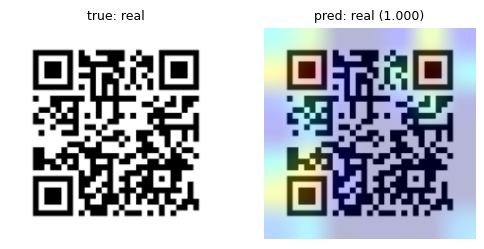

file: real_test_00000.png | true=real | predicted=real (score=1.0000) | tamper_type=n/a
------------------------------------------------------------


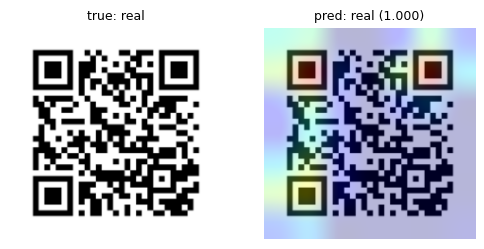

file: real_test_00001.png | true=real | predicted=real (score=1.0000) | tamper_type=n/a
------------------------------------------------------------


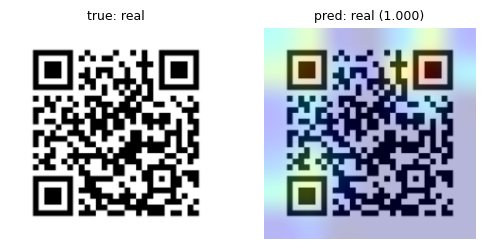

file: real_test_00002.png | true=real | predicted=real (score=1.0000) | tamper_type=n/a
------------------------------------------------------------


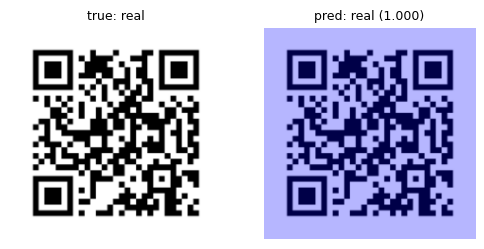

file: real_test_00003.png | true=real | predicted=real (score=1.0000) | tamper_type=n/a
------------------------------------------------------------


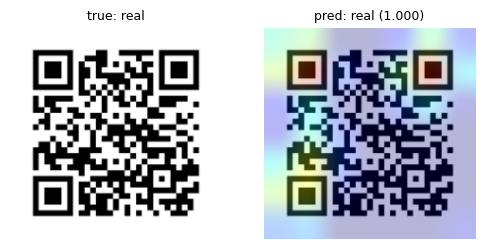

file: real_test_00004.png | true=real | predicted=real (score=1.0000) | tamper_type=n/a
------------------------------------------------------------


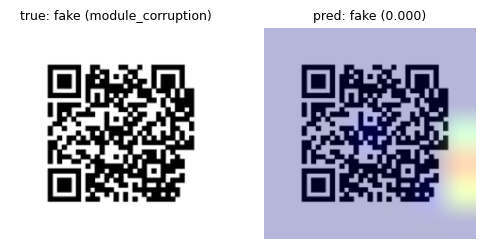

file: fake_test_00000.png | true=fake | predicted=fake (score=0.0000) | tamper_type=module_corruption
------------------------------------------------------------


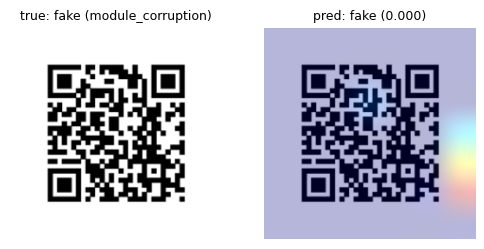

file: fake_test_00001.png | true=fake | predicted=fake (score=0.0000) | tamper_type=module_corruption
------------------------------------------------------------


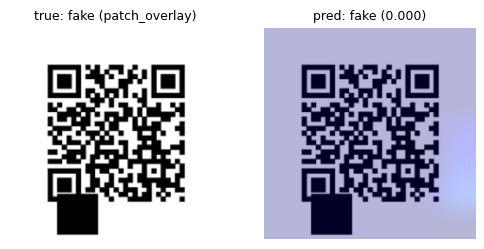

file: fake_test_00002.png | true=fake | predicted=fake (score=0.0000) | tamper_type=patch_overlay
------------------------------------------------------------


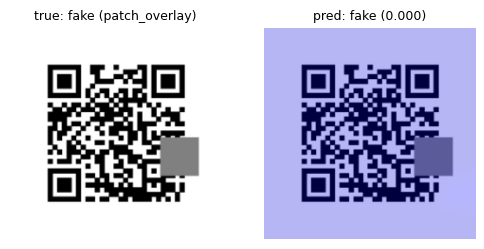

file: fake_test_00003.png | true=fake | predicted=fake (score=0.0000) | tamper_type=patch_overlay
------------------------------------------------------------


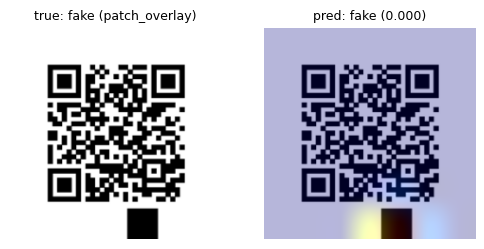

file: fake_test_00004.png | true=fake | predicted=fake (score=0.0000) | tamper_type=patch_overlay
------------------------------------------------------------


In [ ]:
# =========================================================
# GRAD-CAM DISPLAY — run this AFTER training, in the same
# notebook session (needs: model, base_model, gap_layer,
# dropout_layer, dense_layer, class_names, preprocess_input,
# test_files, test_labels — all already exist from the main script)
# =========================================================
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
import csv, os

N_SAMPLES = 10   # change this to show more/fewer

# ---- locate last conv layer once ----
LAST_CONV_LAYER = None
for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D) or "top_conv" in layer.name:
        LAST_CONV_LAYER = layer.name
        break

grad_base = tf.keras.models.Model(
    base_model.input,
    [base_model.get_layer(LAST_CONV_LAYER).output, base_model.output],
)

def make_gradcam_heatmap(img_array):
    with tf.GradientTape() as tape:
        conv_outputs, feat_map = grad_base(img_array, training=False)
        tape.watch(conv_outputs)
        x = gap_layer(feat_map)
        x = dropout_layer(x, training=False)
        preds = dense_layer(x)
        class_channel = preds[:, 0]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), float(preds[0, 0].numpy())

def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap_u8 = np.uint8(255 * heatmap)
    jet = matplotlib.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_u8]
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    overlay = jet_heatmap * alpha + img
    return tf.keras.utils.array_to_img(overlay)

# ---- optional: load tamper category log if it exists, to caption fake samples ----
tamper_lookup = {}
for log_dir in [FAKE_TRAIN_DIR, FAKE_TEST_DIR]:
    log_path = os.path.join(log_dir, "tamper_log.csv")
    if not os.path.exists(log_path):
        log_path = os.path.join(log_dir, "tamper_log_test.csv")
    if os.path.exists(log_path):
        with open(log_path) as f:
            for row in csv.DictReader(f):
                tamper_lookup[row["filename"]] = row.get("category", "")

# ---- pick N_SAMPLES: mix of real and fake so both are visible ----
real_paths = [p for p, l in zip(test_files, test_labels) if l == 1][:N_SAMPLES // 2]
fake_paths = [p for p, l in zip(test_files, test_labels) if l == 0][:N_SAMPLES - len(real_paths)]
sample_paths = real_paths + fake_paths
sample_labels = [1] * len(real_paths) + [0] * len(fake_paths)

print(f"Showing {len(sample_paths)} Grad-CAM samples "
      f"({len(real_paths)} real, {len(fake_paths)} fake)\n")

for path, true_label in zip(sample_paths, sample_labels):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE).numpy()

    img_array = preprocess_input(np.expand_dims(img.copy(), axis=0))
    heatmap, pred_score = make_gradcam_heatmap(img_array)
    overlayed = overlay_gradcam(img, heatmap)

    true_name = class_names[true_label]
    pred_name = class_names[int(pred_score > 0.5)]
    fname = os.path.basename(path)
    category = tamper_lookup.get(fname, "")

    fig, ax = plt.subplots(1, 2, figsize=(6, 3))
    ax[0].imshow(img.astype("uint8"))
    title = f"true: {true_name}"
    if category:
        title += f" ({category})"
    ax[0].set_title(title, fontsize=9)
    ax[0].axis("off")
    ax[1].imshow(overlayed)
    ax[1].set_title(f"pred: {pred_name} ({pred_score:.3f})", fontsize=9)
    ax[1].axis("off")
    plt.show()   # <-- displays inline in the notebook
    print(f"file: {fname} | true={true_name} | predicted={pred_name} "
          f"(score={pred_score:.4f}) | tamper_type={category or 'n/a'}")
    print("-" * 60)

In [ ]:
from google.colab import files

# model is already saved to Drive at this path (from the training script):
# /content/drive/MyDrive/qr_dataset/qr_tamper_effnetb0.keras

# this triggers a browser download of that file to your PC
files.download("/content/drive/MyDrive/qr_dataset/qr_tamper_effnetb0.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("/content/qr_tamper_effnetb0.keras")

In [ ]:
# =========================================================
# CHECK 1 — verify no duplicate QR payloads across
# train / val / test, and no repeated payloads within splits.
# Run this once, after your 4 dataset folders exist.
# =========================================================
!apt-get update && apt-get install -y zbar-tools
!pip install pyzbar

REAL_TRAIN_DIR = "/content/drive/MyDrive/qr_dataset/real_qr_full"
REAL_TEST_DIR  = "/content/drive/MyDrive/qr_dataset/real_qr_test"

from pyzbar.pyzbar import decode
from PIL import Image
import glob, os
from collections import Counter

def decode_all(folder):
    """Decode every QR in a folder, return {filename: payload_or_None}."""
    results = {}
    files = sorted(glob.glob(os.path.join(folder, "**", "*.png"), recursive=True))
    for f in files:
        try:
            found = decode(Image.open(f))
            results[f] = found[0].data.decode("utf-8") if found else None
        except Exception as e:
            results[f] = None
    return results

# only real images carry a real decodable payload — tampered ones may or may not
# decode depending on how much was corrupted, so we check real images here,
# which is what matters for "is my QR content unique / non-overlapping".
real_train = decode_all(REAL_TRAIN_DIR)
real_test  = decode_all(REAL_TEST_DIR)

train_payloads = [p for p in real_train.values() if p is not None]
test_payloads  = [p for p in real_test.values() if p is not None]

undecodable_train = sum(1 for p in real_train.values() if p is None)
undecodable_test  = sum(1 for p in real_test.values() if p is None)
print(f"Real train: {len(real_train)} images, {undecodable_train} failed to decode")
print(f"Real test:  {len(real_test)} images, {undecodable_test} failed to decode")

# --- duplicates WITHIN each split ---
train_dupes = [p for p, c in Counter(train_payloads).items() if c > 1]
test_dupes  = [p for p, c in Counter(test_payloads).items() if c > 1]
print(f"\nDuplicate payloads within train: {len(train_dupes)}")
print(f"Duplicate payloads within test:  {len(test_dupes)}")

# --- overlap BETWEEN train and test (the important leakage check) ---
overlap = set(train_payloads) & set(test_payloads)
print(f"\nPayloads appearing in BOTH train and test: {len(overlap)}")
if overlap:
    print("LEAKAGE DETECTED — these payloads must be removed from one split:")
    for p in list(overlap)[:10]:
        print("  ", p)
else:
    print("No leakage between train and test payloads. Good.")

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

Model loaded.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,154,824 (31.11 MB)

 Trainable params: 2,051,985 (7.83 MB)

 Non-trainable params: 1,998,867 (7.63 MB)

 Optimizer params: 4,103,972 (15.66 MB)

base_model: efficientnetb0 | gap: gap | dense: head_dense | dropout: dropout
Test set: 3000 real, 3000 fake

=== Classification report ===
              precision    recall  f1-score   support

        fake     1.0000    1.0000    1.0000      3000
        real     1.0000    1.0000    1.0000      3000

    accuracy                         1.0000      6000
   macro avg     1.0000    1.0000    1.0000      6000
weighted avg     1.0000    1.0000    1.0000      6000

Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
ROC-AUC:   1.0000


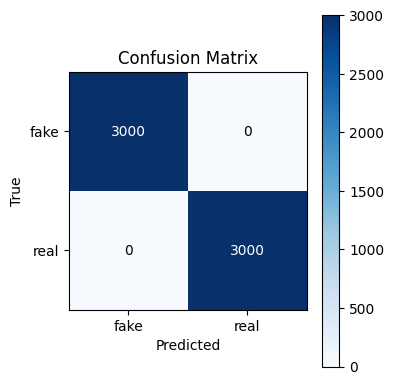

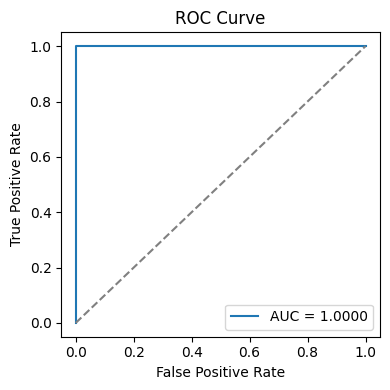


Showing 10 Grad-CAM samples (5 real, 5 fake)



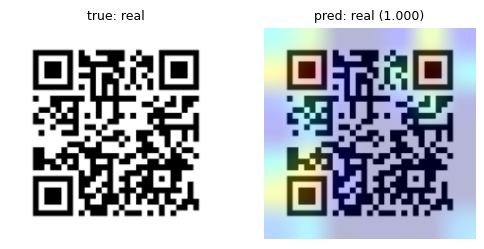

file: real_test_00000.png | true=real | predicted=real (score=1.0000) | tamper_type=n/a
------------------------------------------------------------


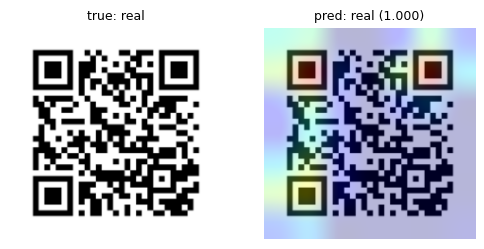

file: real_test_00001.png | true=real | predicted=real (score=1.0000) | tamper_type=n/a
------------------------------------------------------------


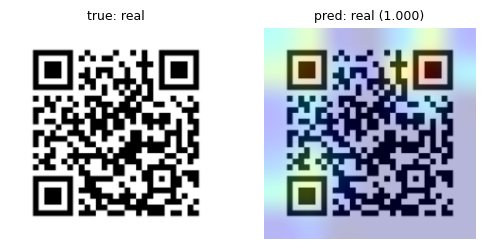

file: real_test_00002.png | true=real | predicted=real (score=1.0000) | tamper_type=n/a
------------------------------------------------------------


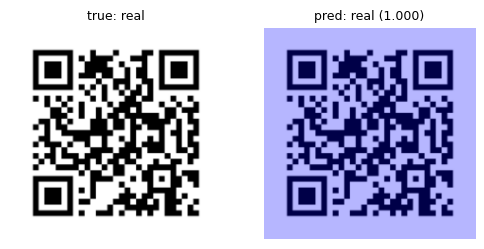

file: real_test_00003.png | true=real | predicted=real (score=1.0000) | tamper_type=n/a
------------------------------------------------------------


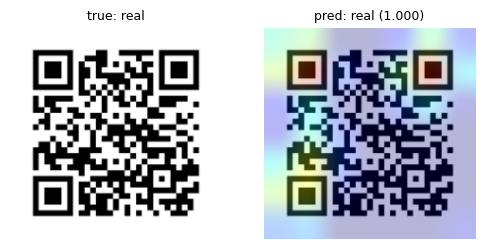

file: real_test_00004.png | true=real | predicted=real (score=1.0000) | tamper_type=n/a
------------------------------------------------------------


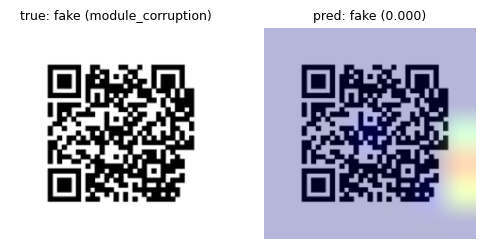

file: fake_test_00000.png | true=fake | predicted=fake (score=0.0000) | tamper_type=module_corruption
------------------------------------------------------------


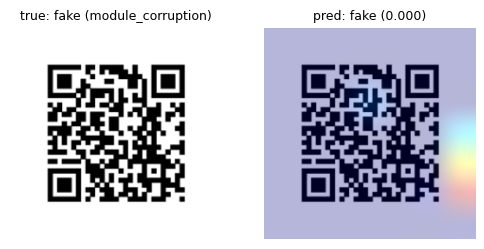

file: fake_test_00001.png | true=fake | predicted=fake (score=0.0000) | tamper_type=module_corruption
------------------------------------------------------------


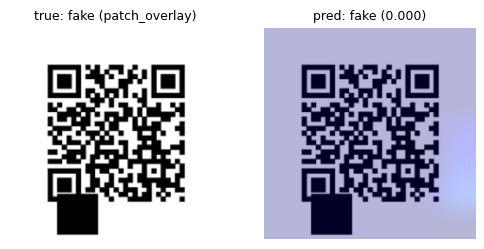

file: fake_test_00002.png | true=fake | predicted=fake (score=0.0000) | tamper_type=patch_overlay
------------------------------------------------------------


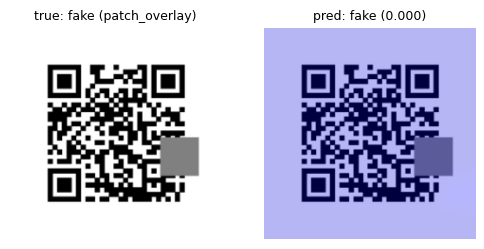

file: fake_test_00003.png | true=fake | predicted=fake (score=0.0000) | tamper_type=patch_overlay
------------------------------------------------------------


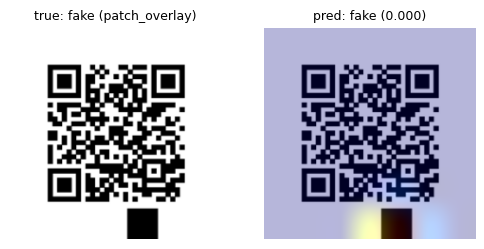

file: fake_test_00004.png | true=fake | predicted=fake (score=0.0000) | tamper_type=patch_overlay
------------------------------------------------------------


In [ ]:
# =========================================================
# LOAD SAVED MODEL AND RUN EVERYTHING — no retraining needed.
# This is fully standalone: just needs the saved .keras file
# and your test image folders. Run this in a fresh session.
# =========================================================
import os, glob, csv
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
import matplotlib
import matplotlib.pyplot as plt

# ---- CONFIG ----
MODEL_PATH   = "/content/drive/MyDrive/qr_dataset/qr_tamper_effnetb0.keras"
REAL_TEST_DIR = "/content/drive/MyDrive/qr_dataset/real_qr_test"   # or your Drive path directly
FAKE_TEST_DIR = "/content/drive/MyDrive/qr_dataset/fake_qr_test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_NAMES = ["fake", "real"]   # label 0 = fake, 1 = real

# =========================================================
# 1. LOAD MODEL
# =========================================================
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded.")
model.summary()

# find the EfficientNet sub-model (base_model) inside the loaded model
base_model = None
for l in model.layers:
    if isinstance(l, tf.keras.Model):
        base_model = l
        break
assert base_model is not None, "Could not find the EfficientNet sub-model inside the loaded model."

gap_layer = model.get_layer("gap")
dense_layer = model.get_layer("head_dense")
dropout_layer = None
for l in model.layers:
    if isinstance(l, tf.keras.layers.Dropout):
        dropout_layer = l
        break

print("base_model:", base_model.name, "| gap:", gap_layer.name,
      "| dense:", dense_layer.name, "| dropout:", dropout_layer.name if dropout_layer else None)

# =========================================================
# 2. REBUILD TEST DATA from the test folders (no training data needed)
# =========================================================
def find_pngs(folder):
    return sorted(glob.glob(os.path.join(folder, "**", "*.png"), recursive=True))

real_test_files = find_pngs(REAL_TEST_DIR)
fake_test_files = find_pngs(FAKE_TEST_DIR)
assert len(real_test_files) > 0, f"No files found in {REAL_TEST_DIR}"
assert len(fake_test_files) > 0, f"No files found in {FAKE_TEST_DIR}"

test_files = real_test_files + fake_test_files
test_labels = [1] * len(real_test_files) + [0] * len(fake_test_files)
print(f"Test set: {len(real_test_files)} real, {len(fake_test_files)} fake")

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

def make_ds(files, labels, batch_size):
    ds = tf.data.Dataset.from_tensor_slices((list(files), list(labels)))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    return ds

test_ds_raw = make_ds(test_files, test_labels, BATCH_SIZE)

# =========================================================
# 3. METRICS — Precision, Recall, F1, Confusion Matrix, ROC-AUC
# =========================================================
y_true, y_pred_prob = [], []
for images, labels in test_ds_raw:
    preprocessed = preprocess_input(images.numpy().copy())
    probs = model.predict(preprocessed, verbose=0).flatten()
    y_pred_prob.extend(probs.tolist())
    y_true.extend(labels.numpy().tolist())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n=== Classification report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_true, y_pred_prob):.4f}")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks([0, 1]); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.title("Confusion Matrix")
plt.colorbar(im)
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_pred_prob):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 4. GRAD-CAM on at least 10 samples
# =========================================================
LAST_CONV_LAYER = None
for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D) or "top_conv" in layer.name:
        LAST_CONV_LAYER = layer.name
        break

grad_base = tf.keras.models.Model(
    base_model.input,
    [base_model.get_layer(LAST_CONV_LAYER).output, base_model.output],
)

def make_gradcam_heatmap(img_array):
    with tf.GradientTape() as tape:
        conv_outputs, feat_map = grad_base(img_array, training=False)
        tape.watch(conv_outputs)
        x = gap_layer(feat_map)
        if dropout_layer is not None:
            x = dropout_layer(x, training=False)
        preds = dense_layer(x)
        class_channel = preds[:, 0]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), float(preds[0, 0].numpy())

def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap_u8 = np.uint8(255 * heatmap)
    jet = matplotlib.colormaps.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_u8]
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    overlay = jet_heatmap * alpha + img
    return tf.keras.utils.array_to_img(overlay)

tamper_lookup = {}
log_path = os.path.join(FAKE_TEST_DIR, "tamper_log_test.csv")
if not os.path.exists(log_path):
    log_path = os.path.join(FAKE_TEST_DIR, "tamper_log.csv")
if os.path.exists(log_path):
    with open(log_path) as f:
        for row in csv.DictReader(f):
            tamper_lookup[row["filename"]] = row.get("category", "")

N_SAMPLES = 10
real_paths = real_test_files[:N_SAMPLES // 2]
fake_paths = fake_test_files[:N_SAMPLES - len(real_paths)]
sample_paths = real_paths + fake_paths
sample_labels = [1] * len(real_paths) + [0] * len(fake_paths)

print(f"\nShowing {len(sample_paths)} Grad-CAM samples "
      f"({len(real_paths)} real, {len(fake_paths)} fake)\n")

for path, true_label in zip(sample_paths, sample_labels):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE).numpy()

    img_array = preprocess_input(np.expand_dims(img.copy(), axis=0))
    heatmap, pred_score = make_gradcam_heatmap(img_array)
    overlayed = overlay_gradcam(img, heatmap)

    true_name = CLASS_NAMES[true_label]
    pred_name = CLASS_NAMES[int(pred_score > 0.5)]
    fname = os.path.basename(path)
    category = tamper_lookup.get(fname, "")

    fig, ax = plt.subplots(1, 2, figsize=(6, 3))
    ax[0].imshow(img.astype("uint8"))
    title = f"true: {true_name}"
    if category:
        title += f" ({category})"
    ax[0].set_title(title, fontsize=9)
    ax[0].axis("off")
    ax[1].imshow(overlayed)
    ax[1].set_title(f"pred: {pred_name} ({pred_score:.3f})", fontsize=9)
    ax[1].axis("off")
    plt.show()
    print(f"file: {fname} | true={true_name} | predicted={pred_name} "
          f"(score={pred_score:.4f}) | tamper_type={category or 'n/a'}")
    print("-" * 60)